# Standard Problem Domainwall Pinning


## Google Colab Link

The demo can be run on Google Colab without any local installation.
Use the following [link](https://colab.research.google.com/drive/1LgIX3o4e_6bww-RtIzJLX38QabUC5QMB) to try it out.

In [12]:
!pip install -q magnumnp numpy==1.22.4

## Run Demo:

In [13]:
from magnumnp import *
import numpy as np

Timer.enable()
Hextmax=2.5/constants.mu_0
Hextmin=0.0/constants.mu_0
tfinal = 20e-9

n  = (80, 1, 1)
dx = (1e-9, 1e-9, 1e-9)
origin = (-n[0]*dx[0]/2., -n[1]*dx[1]/2., -n[2]*dx[2]/2.,)
mesh = Mesh(n, dx, origin)
state = State(mesh)
state.material = {"alpha": 1.}
x, y, z = state.SpatialCoordinate()

soft = (x < 0)
hard = (x >= 0)

Ms = state.Constant([0.0]) 
Ms[soft] = 0.25/constants.mu_0
Ms[hard] = 1./constants.mu_0

Ku = state.Constant([0.0]) 
Ku[soft] = 1e5 
Ku[hard] = 1e6 

A = state.Constant([0.0]) 
A[soft] = 0.25e-11
A[hard] = 1.e-11

state.material['Ms'] = Ms
state.material['A'] = A
state.material['Ku'] = Ku
state.material['Ku_axis'] = [0,1,0]

state.m = state.Constant([np.sin(0.3), np.cos(0.3), 0.0]) 
state.m[hard] = state.Tensor([0.0, -1.0, 0.0])
state.m.normalize()

exchange = ExchangeField()
aniso = UniaxialAnisotropyField()

external = ExternalField(lambda t: state.Constant([0, (Hextmax-Hextmin)*t/tfinal+Hextmin, 0]))

llg = LLGSolver([exchange, aniso, external])
logger = ScalarLogger("data/m.dat", ['t', external.h, 'm'])
while state.t < tfinal:
    llg.step(state, 1e-11)
    logger << state

Timer.print_report()


2023-05-08 12:47:09  magnum.np:INFO [State] running on device: cpu (dtype = float64)
2023-05-08 12:47:09  magnum.np:INFO [Mesh] 80x1x1 (size= 1e-09 x 1e-09 x 1e-09)
2023-05-08 12:47:09  magnum.np:INFO [LLGSolver] using RKF45 solver (atol = 1e-05)
2023-05-08 12:47:10  magnum.np:INFO [LLG] step: dt= 1e-11  t=1e-11
2023-05-08 12:47:11  magnum.np:INFO [LLG] step: dt= 1e-11  t=2e-11
2023-05-08 12:47:12  magnum.np:INFO [LLG] step: dt= 1e-11  t=3e-11
2023-05-08 12:47:13  magnum.np:INFO [LLG] step: dt= 1e-11  t=4e-11
2023-05-08 12:47:14  magnum.np:INFO [LLG] step: dt= 1e-11  t=5e-11
2023-05-08 12:47:14  magnum.np:INFO [LLG] step: dt= 1e-11  t=6e-11
2023-05-08 12:47:15  magnum.np:INFO [LLG] step: dt= 1e-11  t=7e-11
2023-05-08 12:47:16  magnum.np:INFO [LLG] step: dt= 1e-11  t=8e-11
2023-05-08 12:47:16  magnum.np:INFO [LLG] step: dt= 1e-11  t=9e-11
2023-05-08 12:47:17  magnum.np:INFO [LLG] step: dt= 1e-11  t=1e-10
2023-05-08 12:47:18  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.1e-10
2023-05-08 12:

2023-05-08 12:48:27  magnum.np:INFO [LLG] step: dt= 1e-11  t=9.7e-10
2023-05-08 12:48:28  magnum.np:INFO [LLG] step: dt= 1e-11  t=9.8e-10
2023-05-08 12:48:29  magnum.np:INFO [LLG] step: dt= 1e-11  t=9.9e-10
2023-05-08 12:48:30  magnum.np:INFO [LLG] step: dt= 1e-11  t=1e-09
2023-05-08 12:48:31  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.01e-09
2023-05-08 12:48:31  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.02e-09
2023-05-08 12:48:32  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.03e-09
2023-05-08 12:48:33  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.04e-09
2023-05-08 12:48:34  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.05e-09
2023-05-08 12:48:35  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.06e-09
2023-05-08 12:48:36  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.07e-09
2023-05-08 12:48:37  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.08e-09
2023-05-08 12:48:38  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.09e-09
2023-05-08 12:48:39  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.1e-09
2023-05-08 12:48:40  magnum

2023-05-08 12:49:46  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.95e-09
2023-05-08 12:49:47  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.96e-09
2023-05-08 12:49:48  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.97e-09
2023-05-08 12:49:48  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.98e-09
2023-05-08 12:49:49  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.99e-09
2023-05-08 12:49:50  magnum.np:INFO [LLG] step: dt= 1e-11  t=2e-09
2023-05-08 12:49:51  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.01e-09
2023-05-08 12:49:52  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.02e-09
2023-05-08 12:49:53  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.03e-09
2023-05-08 12:49:54  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.04e-09
2023-05-08 12:49:55  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.05e-09
2023-05-08 12:49:55  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.06e-09
2023-05-08 12:49:56  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.07e-09
2023-05-08 12:49:57  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.08e-09
2023-05-08 12:49:58  ma

2023-05-08 12:51:04  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.93e-09
2023-05-08 12:51:05  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.94e-09
2023-05-08 12:51:06  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.95e-09
2023-05-08 12:51:07  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.96e-09
2023-05-08 12:51:07  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.97e-09
2023-05-08 12:51:08  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.98e-09
2023-05-08 12:51:09  magnum.np:INFO [LLG] step: dt= 1e-11  t=2.99e-09
2023-05-08 12:51:10  magnum.np:INFO [LLG] step: dt= 1e-11  t=3e-09
2023-05-08 12:51:11  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.01e-09
2023-05-08 12:51:11  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.02e-09
2023-05-08 12:51:12  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.03e-09
2023-05-08 12:51:13  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.04e-09
2023-05-08 12:51:14  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.05e-09
2023-05-08 12:51:15  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.06e-09
2023-05-08 12:51:16  ma

2023-05-08 12:52:15  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.91e-09
2023-05-08 12:52:16  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.92e-09
2023-05-08 12:52:17  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.93e-09
2023-05-08 12:52:17  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.94e-09
2023-05-08 12:52:18  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.95e-09
2023-05-08 12:52:18  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.96e-09
2023-05-08 12:52:19  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.97e-09
2023-05-08 12:52:20  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.98e-09
2023-05-08 12:52:20  magnum.np:INFO [LLG] step: dt= 1e-11  t=3.99e-09
2023-05-08 12:52:21  magnum.np:INFO [LLG] step: dt= 1e-11  t=4e-09
2023-05-08 12:52:21  magnum.np:INFO [LLG] step: dt= 1e-11  t=4.01e-09
2023-05-08 12:52:22  magnum.np:INFO [LLG] step: dt= 1e-11  t=4.02e-09
2023-05-08 12:52:23  magnum.np:INFO [LLG] step: dt= 1e-11  t=4.03e-09
2023-05-08 12:52:23  magnum.np:INFO [LLG] step: dt= 1e-11  t=4.04e-09
2023-05-08 12:52:24  ma

...

2023-05-08 13:02:47  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.658e-08
2023-05-08 13:02:47  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.659e-08
2023-05-08 13:02:48  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.66e-08
2023-05-08 13:02:48  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.661e-08
2023-05-08 13:02:48  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.662e-08
2023-05-08 13:02:49  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.663e-08
2023-05-08 13:02:49  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.664e-08
2023-05-08 13:02:49  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.665e-08
2023-05-08 13:02:49  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.666e-08
2023-05-08 13:02:50  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.667e-08
2023-05-08 13:02:50  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.668e-08
2023-05-08 13:02:50  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.669e-08
2023-05-08 13:02:50  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.67e-08
2023-05-08 13:02:51  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.671e-08
2023-05-

2023-05-08 13:03:14  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.755e-08
2023-05-08 13:03:14  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.756e-08
2023-05-08 13:03:14  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.757e-08
2023-05-08 13:03:15  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.758e-08
2023-05-08 13:03:15  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.759e-08
2023-05-08 13:03:15  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.76e-08
2023-05-08 13:03:15  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.761e-08
2023-05-08 13:03:16  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.762e-08
2023-05-08 13:03:16  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.763e-08
2023-05-08 13:03:16  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.764e-08
2023-05-08 13:03:16  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.765e-08
2023-05-08 13:03:17  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.766e-08
2023-05-08 13:03:17  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.767e-08
2023-05-08 13:03:17  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.768e-08
2023-05

2023-05-08 13:03:40  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.852e-08
2023-05-08 13:03:41  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.853e-08
2023-05-08 13:03:41  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.854e-08
2023-05-08 13:03:41  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.855e-08
2023-05-08 13:03:41  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.856e-08
2023-05-08 13:03:42  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.857e-08
2023-05-08 13:03:42  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.858e-08
2023-05-08 13:03:42  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.859e-08
2023-05-08 13:03:43  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.86e-08
2023-05-08 13:03:43  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.861e-08
2023-05-08 13:03:43  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.862e-08
2023-05-08 13:03:43  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.863e-08
2023-05-08 13:03:44  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.864e-08
2023-05-08 13:03:44  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.865e-08
2023-05

2023-05-08 13:04:07  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.949e-08
2023-05-08 13:04:07  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.95e-08
2023-05-08 13:04:07  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.951e-08
2023-05-08 13:04:08  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.952e-08
2023-05-08 13:04:08  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.953e-08
2023-05-08 13:04:08  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.954e-08
2023-05-08 13:04:09  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.955e-08
2023-05-08 13:04:09  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.956e-08
2023-05-08 13:04:09  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.957e-08
2023-05-08 13:04:09  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.958e-08
2023-05-08 13:04:10  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.959e-08
2023-05-08 13:04:10  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.96e-08
2023-05-08 13:04:10  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.961e-08
2023-05-08 13:04:10  magnum.np:INFO [LLG] step: dt= 1e-11  t=1.962e-08
2023-05-


TIMER REPORT
Operation                                    No of calls    Avg time [ms]    Total time [s]
-----------------------------------------  -------------  ---------------  ----------------
LLGSolver.step                                      2283       480.905          1097.91
    ExchangeField.h                               656306         0.308665        202.579
    UniaxialAnisotropyField.h                     656306         0.271603        178.255
    ExternalField.h                               656325         0.268436        176.182
    LLGSolver.step                                    19       290.308             5.51586
        ExchangeField.h                             5614         0.178445          1.00179
            LLGSolver.step                          2000       513.678          1027.36
                ExchangeField.h                   575472         0.313705        180.528
                UniaxialAnisotropyField.h         575472         0.29            166.887

## Plot Results:

In [19]:
from os import path
if not path.isdir("ref"):
    !mkdir ref
    !wget -P ref https://gitlab.com/magnum.np/magnum.np/raw/main/demos/sp_domainwall_pinning/ref/m_ref.dat
    !wget -P ref https://gitlab.com/magnum.np/magnum.np/raw/main/demos/sp_domainwall_pinning/ref/m_dieter.dat
    !wget -P ref https://gitlab.com/magnum.np/magnum.np/raw/main/demos/sp_domainwall_pinning/ref/m_magnumaf.dat

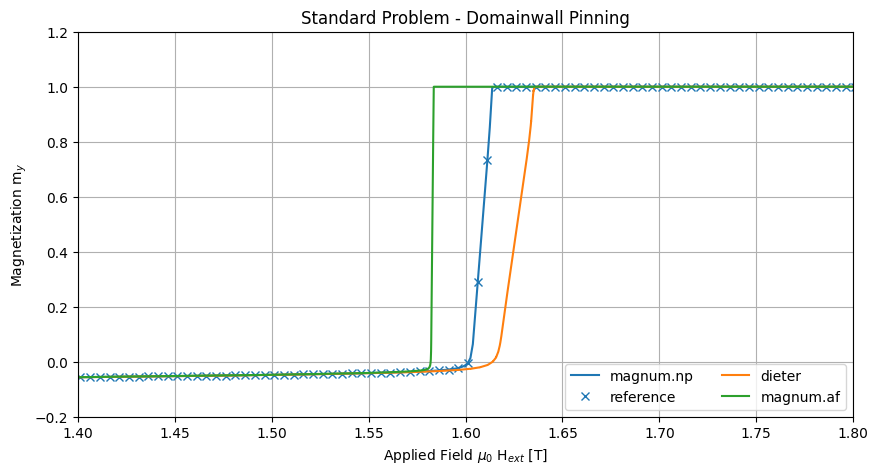

In [20]:
import matplotlib.pyplot as plt

data = np.loadtxt("data/m.dat")
ref = np.loadtxt("ref/m_ref.dat")
data_dieter = np.loadtxt("ref/m_dieter.dat")
data_magnumaf = np.loadtxt("ref/m_magnumaf.dat")


fig, ax = plt.subplots(figsize=(10,5))
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax.plot(data[:,2]*4*np.pi*1e-7, data[:,5], '-', color = cycle[0], label = "magnum.np")
ax.plot(ref[:,2][0::4]*4*np.pi*1e-7, ref[:,5][0::4], 'x', color = cycle[0], linewidth = 6, label = "reference")
ax.plot(data_dieter[:,1], data_dieter[:,3], '-', color = cycle[1], label = "dieter")
ax.plot(data_magnumaf[:,4]*4*np.pi*1e-7, data_magnumaf[:,2], '-', color = cycle[2], label = "magnum.af")

ax.set_xlim([1.4,1.8])
ax.set_ylim([-0.2,1.2])
ax.set_title("Standard Problem - Domainwall Pinning")
ax.set_xlabel("Applied Field $\mu$$_0$ H$_{ext}$ [T]")
ax.set_ylabel("Magnetization m$_y$")
ax.legend(ncol=2, loc='lower right')
ax.grid()
fig.savefig("data/results.png")
